In [10]:
# ============================================================
# BranchyNet + Adaptive Computation — ResNet-50 on CIFAR-10
# Early-Exit Inference with Confidence-Based Adaptive Depth
# Compatible with baseline: __2__baseline_resnet50_cifar10.pth
# Output: branchynet_metrics.json (compare with baseline_metrics.json)
# ============================================================

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import time, os, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
from thop import profile
from PIL import Image

In [11]:
# ── REPRODUCIBILITY ───────────────────────────────────────────
SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

In [12]:
# ── CONFIG ────────────────────────────────────────────────────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE  = 128
EPOCHS      = 50
NUM_CLASSES = 10
SAVE_PATH   = "__3__branchynet_resnet50_cifar10.pth"

# Exit confidence thresholds to sweep during evaluation
# A lower threshold → more samples exit early (faster, possibly less accurate)
# A higher threshold → fewer samples exit early (slower, more accurate)
EXIT_THRESHOLDS = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]

# Branch loss weights: [exit1, exit2, final]
# Earlier exits get lower weight so final head still dominates training
BRANCH_WEIGHTS = [0.3, 0.3, 0.4]

CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

print(f"Using device: {DEVICE}")

Using device: cuda


In [13]:
# ── AUXILIARY BRANCH (early-exit classifier head) ─────────────
# Lightweight head attached at intermediate ResNet layers.
# Uses global average pooling + BN + small FC to keep overhead minimal.

class EarlyExitBranch(nn.Module):
    """
    Tiny classifier head attached to an intermediate feature map.
    input_channels : number of channels from the tapped ResNet layer
    num_classes    : number of output classes
    """
    def __init__(self, input_channels: int, num_classes: int = 10):
        super().__init__()
        self.branch = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),          # collapse spatial dims → (B, C, 1, 1)
            nn.Flatten(),                      # → (B, C)
            nn.BatchNorm1d(input_channels),
            nn.Linear(input_channels, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.branch(x)

In [14]:
# ── BRANCHYNET MODEL ──────────────────────────────────────────
# We tap ResNet-50 at two intermediate points (after layer1 and layer2)
# plus the standard final head = 3 total exits.
#
# ResNet-50 channel sizes:
#   layer1 output : 256 channels
#   layer2 output : 512 channels
#   layer4 output : 2048 channels  (final, unchanged)
#
# Architecture adapted for 32×32 exactly like the baseline:
#   conv1  → 3×3 stride-1 (no spatial reduction)
#   maxpool → Identity

class BranchyResNet50(nn.Module):
    """
    ResNet-50 with two auxiliary early-exit branches inserted after
    layer1 (shallow) and layer2 (mid-depth).  The original final
    classifier serves as the third (deepest) exit.
    """
    def __init__(self, num_classes: int = 10, pretrained: bool = True):
        super().__init__()

        # ── backbone ──────────────────────────────────────────
        backbone = models.resnet50(pretrained=pretrained)
        backbone.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1,
                                     padding=1, bias=False)
        backbone.maxpool = nn.Identity()
        backbone.fc      = nn.Linear(backbone.fc.in_features, num_classes)

        # split backbone into named sequential segments
        self.stem    = nn.Sequential(backbone.conv1, backbone.bn1,
                                     backbone.relu, backbone.maxpool)
        self.layer1  = backbone.layer1   # out: 256 ch
        self.layer2  = backbone.layer2   # out: 512 ch
        self.layer3  = backbone.layer3   # out: 1024 ch
        self.layer4  = backbone.layer4   # out: 2048 ch
        self.avgpool = backbone.avgpool
        self.fc      = backbone.fc

        # ── early-exit branches ───────────────────────────────
        self.branch1 = EarlyExitBranch(256,  num_classes)   # after layer1
        self.branch2 = EarlyExitBranch(512,  num_classes)   # after layer2

    # ─ forward: always returns all three logit tensors during training ─
    def forward(self, x):
        x = self.stem(x)

        x = self.layer1(x)
        logits1 = self.branch1(x)          # exit 1

        x = self.layer2(x)
        logits2 = self.branch2(x)          # exit 2

        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        logits3 = self.fc(x)               # exit 3 (final)

        return logits1, logits2, logits3

    # ─ adaptive inference: stop as soon as confidence ≥ threshold ─
    @torch.no_grad()
    def adaptive_forward(self, x, threshold: float = 0.8):
        """
        Returns (logits, exit_index) where exit_index ∈ {0, 1, 2}.
        exit_index=0 means the sample exited at branch1 (earliest).
        """
        x = self.stem(x)

        x = self.layer1(x)
        logits1 = self.branch1(x)
        conf1 = torch.softmax(logits1, dim=1).max(dim=1).values
        # for each sample in the batch, check if it can exit
        # (for batch > 1 during eval we still process all, record per-sample exit)

        x = self.layer2(x)
        logits2 = self.branch2(x)
        conf2 = torch.softmax(logits2, dim=1).max(dim=1).values

        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        logits3 = self.fc(x)

        # per-sample exit decision
        # exit1 if conf1 >= threshold, else exit2 if conf2 >= threshold, else exit3
        exit_logits = logits3.clone()
        exit_idx    = torch.full((x.size(0),), 2, dtype=torch.long)

        mask2 = conf2 >= threshold
        exit_logits[mask2] = logits2[mask2]
        exit_idx[mask2]    = 1

        mask1 = conf1 >= threshold
        exit_logits[mask1] = logits1[mask1]
        exit_idx[mask1]    = 0

        return exit_logits, exit_idx


model = BranchyResNet50(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters (BranchyNet): {total_params:,}")

Total parameters (BranchyNet): 23,623,518


In [15]:
# ── DATA ─────────────────────────────────────────────────────
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True,
                                          download=True, transform=transform_train)
test_set  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                          download=True, transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE,
                                            shuffle=True, num_workers=0,
                                            worker_init_fn=seed_worker,
                                            generator=g)
test_loader  = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE,
                                            shuffle=False, num_workers=0)

print(f"Train: {len(train_set)} | Test: {len(test_set)}")

Train: 50000 | Test: 10000


In [16]:
# ── TRAINING ──────────────────────────────────────────────────
# Multi-exit loss: weighted sum of cross-entropy at each exit.
# Label smoothing applied consistently across all exits.

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1,
                             momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


def branchynet_loss(logits_list, labels, weights=BRANCH_WEIGHTS):
    """Weighted sum of losses from all exit heads."""
    assert len(logits_list) == len(weights), "Mismatch between exits and weights"
    total = sum(w * criterion(logits, labels)
                for w, logits in zip(weights, logits_list))
    return total


def train_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits1, logits2, logits3 = model(inputs)
        loss = branchynet_loss([logits1, logits2, logits3], labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        # accuracy tracked against final exit (most informed head)
        correct += logits3.argmax(1).eq(labels).sum().item()
        total   += labels.size(0)
    return total_loss / len(loader), correct / total


def evaluate_standard(model, loader):
    """Standard accuracy using only the final exit (no early stopping)."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            _, _, logits3 = model(inputs)
            correct += logits3.argmax(1).eq(labels).sum().item()
            total   += labels.size(0)
    return correct / total


best_val_acc = 0.0
train_accs, val_accs, train_losses = [], [], []

print("\n" + "="*60)
print("TRAINING — BranchyNet (3 exits)")
print("="*60)

for epoch in range(EPOCHS):
    loss, train_acc = train_epoch(model, train_loader, optimizer)
    val_acc = evaluate_standard(model, test_loader)
    scheduler.step()

    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_losses.append(loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        marker = " ← best saved"
    else:
        marker = ""

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {loss:.4f} | "
          f"Train: {train_acc:.4f} | Val: {val_acc:.4f}{marker}")

print(f"\nBest validation accuracy (final exit): {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")


TRAINING — BranchyNet (3 exits)
Epoch  1/50 | Loss: 1.3960 | Train: 0.7310 | Val: 0.7822 ← best saved
Epoch  2/50 | Loss: 1.1265 | Train: 0.8509 | Val: 0.8131 ← best saved
Epoch  3/50 | Loss: 1.0609 | Train: 0.8648 | Val: 0.7963
Epoch  4/50 | Loss: 1.0277 | Train: 0.8667 | Val: 0.8404 ← best saved
Epoch  5/50 | Loss: 1.0024 | Train: 0.8732 | Val: 0.8086
Epoch  6/50 | Loss: 0.9861 | Train: 0.8716 | Val: 0.8241
Epoch  7/50 | Loss: 0.9733 | Train: 0.8744 | Val: 0.7636
Epoch  8/50 | Loss: 0.9654 | Train: 0.8718 | Val: 0.8034
Epoch  9/50 | Loss: 0.9543 | Train: 0.8758 | Val: 0.8370
Epoch 10/50 | Loss: 0.9446 | Train: 0.8776 | Val: 0.7460
Epoch 11/50 | Loss: 0.9381 | Train: 0.8785 | Val: 0.7750
Epoch 12/50 | Loss: 0.9263 | Train: 0.8822 | Val: 0.7864
Epoch 13/50 | Loss: 0.9188 | Train: 0.8853 | Val: 0.8106
Epoch 14/50 | Loss: 0.9123 | Train: 0.8862 | Val: 0.8399
Epoch 15/50 | Loss: 0.9048 | Train: 0.8879 | Val: 0.7822
Epoch 16/50 | Loss: 0.8943 | Train: 0.8937 | Val: 0.8518 ← best saved
Epo

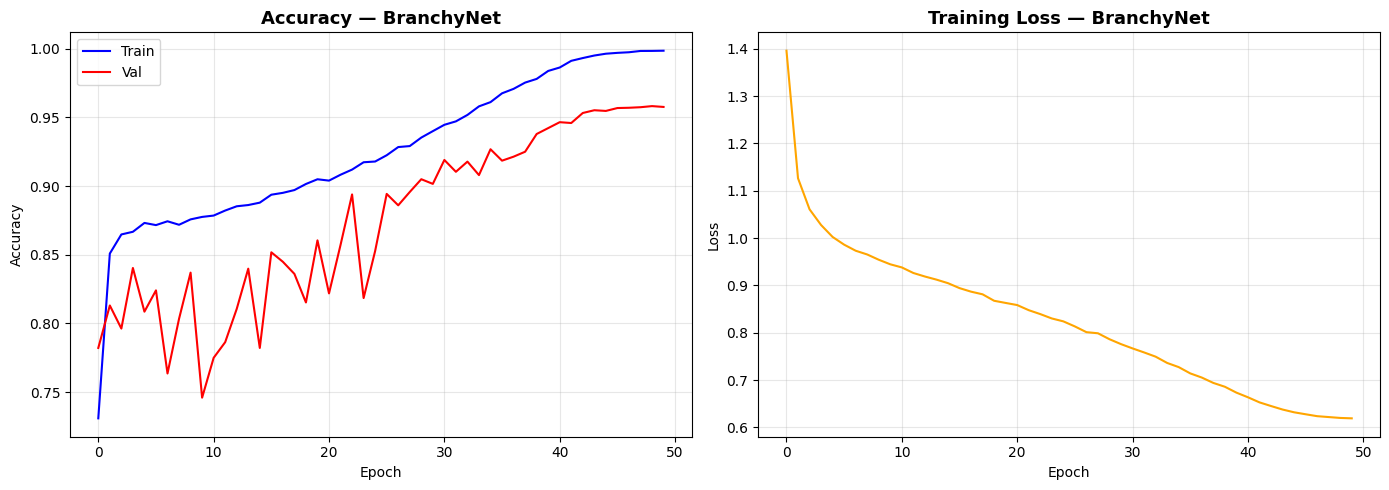

In [17]:
# ── TRAINING CURVES ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_accs, label='Train', color='blue')
ax1.plot(val_accs,   label='Val',   color='red')
ax1.set_title('Accuracy — BranchyNet', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(train_losses, color='orange')
ax2.set_title('Training Loss — BranchyNet', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('__3__training_curves.png', dpi=150)
plt.show()

In [18]:
# ── FULL EVALUATION (standard — final exit only) ──────────────
print("\n" + "="*60)
print("FULL EVALUATION — final exit (no early stopping)")
print("="*60)

model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        _, _, logits3 = model(inputs)
        preds = logits3.argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc_final  = accuracy_score(all_labels, all_preds)
prec_final = precision_score(all_labels, all_preds, average='macro')
rec_final  = recall_score(all_labels, all_preds, average='macro')
f1_final   = f1_score(all_labels, all_preds, average='macro')

print(f"\n  Accuracy          : {acc_final:.4f}  ({acc_final*100:.2f}%)")
print(f"  Precision (macro) : {prec_final:.4f}")
print(f"  Recall    (macro) : {rec_final:.4f}")
print(f"  F1-score  (macro) : {f1_final:.4f}")
print("\nPer-class report (final exit):")
print(classification_report(all_labels, all_preds,
                             target_names=CIFAR10_CLASSES, digits=4))


FULL EVALUATION — final exit (no early stopping)

  Accuracy          : 0.9582  (95.82%)
  Precision (macro) : 0.9581
  Recall    (macro) : 0.9582
  F1-score  (macro) : 0.9581

Per-class report (final exit):
              precision    recall  f1-score   support

    airplane     0.9612    0.9650    0.9631      1000
  automobile     0.9714    0.9840    0.9776      1000
        bird     0.9521    0.9540    0.9530      1000
         cat     0.9201    0.8870    0.9033      1000
        deer     0.9558    0.9720    0.9638      1000
         dog     0.9169    0.9270    0.9219      1000
        frog     0.9695    0.9850    0.9772      1000
       horse     0.9827    0.9660    0.9743      1000
        ship     0.9721    0.9740    0.9730      1000
       truck     0.9798    0.9680    0.9738      1000

    accuracy                         0.9582     10000
   macro avg     0.9581    0.9582    0.9581     10000
weighted avg     0.9581    0.9582    0.9581     10000



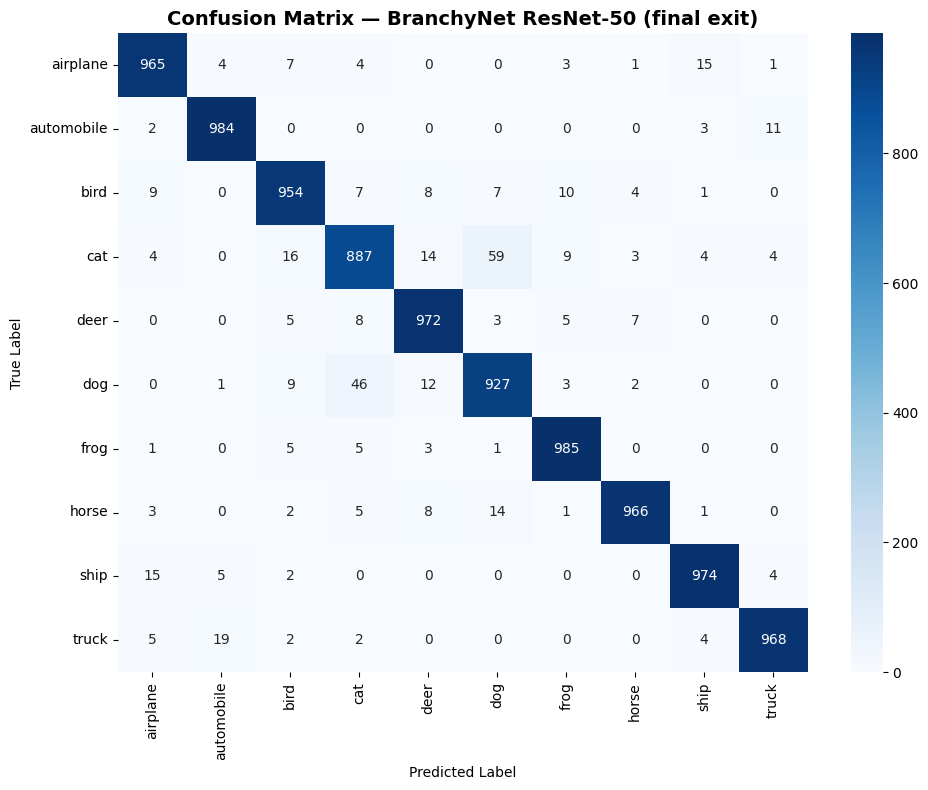

In [19]:
# ── CONFUSION MATRIX (final exit) ────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES)
plt.title('Confusion Matrix — BranchyNet ResNet-50 (final exit)',
          fontsize=14, fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('__3__confusion_matrix.png', dpi=150)
plt.show()

In [20]:
# ── ADAPTIVE COMPUTATION EVALUATION ──────────────────────────
# Sweep over confidence thresholds τ.
# For each τ, run adaptive_forward on the test set and record:
#   - accuracy
#   - fraction of samples exiting at each branch
#   - average inference time per sample
# This section IS the "Adaptive Computation" part of the experiment.

print("\n" + "="*60)
print("ADAPTIVE COMPUTATION — Early-Exit Threshold Sweep")
print("="*60)
print(f"  Thresholds tested: {EXIT_THRESHOLDS}")

adaptive_results = []   # one entry per threshold

for tau in EXIT_THRESHOLDS:
    preds_list, labels_list, exit_idx_list = [], [], []

    t_start = time.time()
    model.eval()
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(DEVICE)
            logits, exit_idx = model.adaptive_forward(inputs, threshold=tau)
            preds_list.extend(logits.argmax(1).cpu().numpy())
            labels_list.extend(labels.numpy())
            exit_idx_list.extend(exit_idx.cpu().numpy())
    t_end = time.time()

    preds_arr    = np.array(preds_list)
    labels_arr   = np.array(labels_list)
    exit_idx_arr = np.array(exit_idx_list)
    n            = len(labels_arr)

    acc   = accuracy_score(labels_arr, preds_arr)
    prec  = precision_score(labels_arr, preds_arr, average='macro', zero_division=0)
    rec   = recall_score(labels_arr, preds_arr, average='macro', zero_division=0)
    f1    = f1_score(labels_arr, preds_arr, average='macro', zero_division=0)

    frac_exit1 = (exit_idx_arr == 0).mean()
    frac_exit2 = (exit_idx_arr == 1).mean()
    frac_exit3 = (exit_idx_arr == 2).mean()

    avg_time_ms = (t_end - t_start) / n * 1000   # ms per sample

    adaptive_results.append({
        "threshold"  : tau,
        "accuracy"   : round(acc,  4),
        "precision"  : round(prec, 4),
        "recall"     : round(rec,  4),
        "f1"         : round(f1,   4),
        "frac_exit1" : round(frac_exit1, 4),
        "frac_exit2" : round(frac_exit2, 4),
        "frac_exit3" : round(frac_exit3, 4),
        "avg_time_ms": round(avg_time_ms, 4),
    })

    print(f"\n  τ={tau:.2f} | Acc={acc:.4f} | F1={f1:.4f} | "
          f"Exit1={frac_exit1:.1%} Exit2={frac_exit2:.1%} Exit3={frac_exit3:.1%} | "
          f"Time={avg_time_ms:.3f}ms/sample")


ADAPTIVE COMPUTATION — Early-Exit Threshold Sweep
  Thresholds tested: [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]

  τ=0.50 | Acc=0.9193 | F1=0.9190 | Exit1=83.7% Exit2=11.7% Exit3=4.6% | Time=0.530ms/sample

  τ=0.60 | Acc=0.9372 | F1=0.9370 | Exit1=75.8% Exit2=15.4% Exit3=8.8% | Time=0.536ms/sample

  τ=0.70 | Acc=0.9470 | F1=0.9469 | Exit1=67.9% Exit2=17.6% Exit3=14.4% | Time=0.529ms/sample

  τ=0.80 | Acc=0.9540 | F1=0.9539 | Exit1=57.2% Exit2=20.2% Exit3=22.6% | Time=0.532ms/sample

  τ=0.90 | Acc=0.9579 | F1=0.9578 | Exit1=41.1% Exit2=19.2% Exit3=39.7% | Time=0.536ms/sample

  τ=0.95 | Acc=0.9578 | F1=0.9577 | Exit1=25.8% Exit2=13.7% Exit3=60.5% | Time=0.534ms/sample


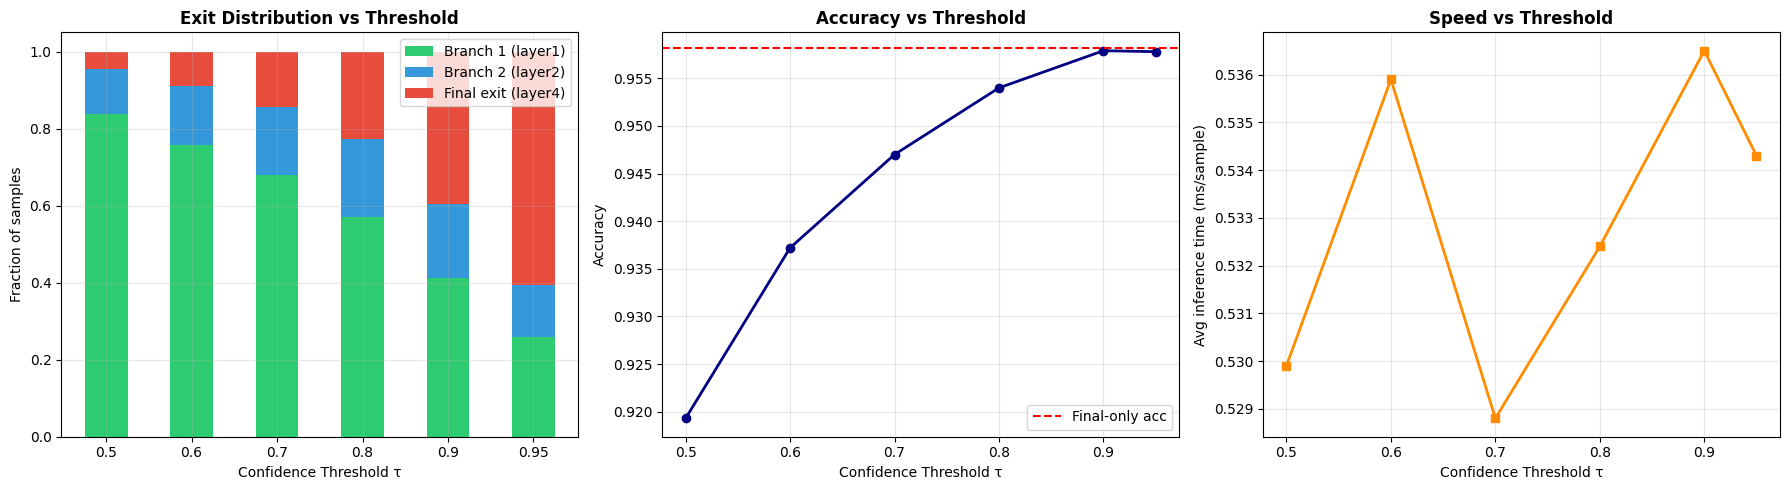

In [21]:
# ── EARLY EXIT DISTRIBUTION PLOT ─────────────────────────────
thresholds_plot = [r["threshold"]   for r in adaptive_results]
frac1_plot      = [r["frac_exit1"]  for r in adaptive_results]
frac2_plot      = [r["frac_exit2"]  for r in adaptive_results]
frac3_plot      = [r["frac_exit3"]  for r in adaptive_results]
acc_plot        = [r["accuracy"]    for r in adaptive_results]
time_plot       = [r["avg_time_ms"] for r in adaptive_results]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Exit distribution stacked bar
x = np.arange(len(thresholds_plot))
width = 0.5
axes[0].bar(x, frac1_plot, width, label='Branch 1 (layer1)', color='#2ecc71')
axes[0].bar(x, frac2_plot, width, bottom=frac1_plot, label='Branch 2 (layer2)', color='#3498db')
axes[0].bar(x, frac3_plot, width,
            bottom=[f1+f2 for f1, f2 in zip(frac1_plot, frac2_plot)],
            label='Final exit (layer4)', color='#e74c3c')
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(t) for t in thresholds_plot])
axes[0].set_xlabel('Confidence Threshold τ')
axes[0].set_ylabel('Fraction of samples')
axes[0].set_title('Exit Distribution vs Threshold', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy vs threshold
axes[1].plot(thresholds_plot, acc_plot, 'o-', color='navy', linewidth=2)
axes[1].axhline(y=acc_final, color='red', linestyle='--', label='Final-only acc')
axes[1].set_xlabel('Confidence Threshold τ')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy vs Threshold', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Inference time vs threshold
axes[2].plot(thresholds_plot, time_plot, 's-', color='darkorange', linewidth=2)
axes[2].set_xlabel('Confidence Threshold τ')
axes[2].set_ylabel('Avg inference time (ms/sample)')
axes[2].set_title('Speed vs Threshold', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('__3__adaptive_exit_analysis.png', dpi=150)
plt.show()

In [22]:
# ── MODEL COMPLEXITY METRICS ──────────────────────────────────
print("\n" + "="*60)
print("MODEL COMPLEXITY METRICS")
print("="*60)

size_mb = os.path.getsize(SAVE_PATH) / 1e6
dummy   = torch.randn(1, 3, 32, 32).to(DEVICE)

# FLOPs for the FULL forward pass (all exits computed)
flops, _ = profile(model, inputs=(dummy,), verbose=False)

# Standard inference time (full forward, no early exit)
model.eval()
with torch.no_grad():
    for _ in range(10):
        model(dummy)
    times_full = []
    for _ in range(500):
        t0 = time.time()
        model(dummy)
        times_full.append(time.time() - t0)
inf_ms_full = np.mean(times_full) * 1000

# Adaptive inference time at τ=0.8 (single sample)
with torch.no_grad():
    for _ in range(10):
        model.adaptive_forward(dummy, threshold=0.8)
    times_adapt = []
    for _ in range(500):
        t0 = time.time()
        model.adaptive_forward(dummy, threshold=0.8)
        times_adapt.append(time.time() - t0)
inf_ms_adapt = np.mean(times_adapt) * 1000

print(f"  Parameters          : {total_params:,}")
print(f"  Model size          : {size_mb:.2f} MB")
print(f"  FLOPs (full pass)   : {flops/1e9:.3f} GFLOPs")
print(f"  Inference (full)    : {inf_ms_full:.3f} ms")
print(f"  Inference (τ=0.8)   : {inf_ms_adapt:.3f} ms")


MODEL COMPLEXITY METRICS
  Parameters          : 23,623,518
  Model size          : 94.83 MB
  FLOPs (full pass)   : 1.312 GFLOPs
  Inference (full)    : 5.282 ms
  Inference (τ=0.8)   : 5.677 ms


In [23]:
# ── SAVE COMPREHENSIVE METRICS JSON ───────────────────────────
# JSON structure mirrors baseline_metrics.json PLUS branchynet-specific fields.
# Load both JSONs side by side to compare baseline vs BranchyNet.

branchynet_metrics = {
    # ── Standard final-exit metrics (comparable to baseline) ──
    "model"            : "BranchyNet_ResNet50_CIFAR10",
    "accuracy"         : round(acc_final,  4),
    "precision"        : round(prec_final, 4),
    "recall"           : round(rec_final,  4),
    "f1"               : round(f1_final,   4),
    "params"           : total_params,
    "size_mb"          : round(size_mb, 4),
    "flops_G"          : round(flops / 1e9, 4),
    "inference_ms"     : round(inf_ms_full, 4),

    # ── BranchyNet / Adaptive Computation specific ─────────────
    "num_exits"        : 3,
    "exit_positions"   : ["after layer1 (256ch)", "after layer2 (512ch)", "final fc (2048ch)"],
    "branch_weights"   : BRANCH_WEIGHTS,
    "inference_ms_adaptive_tau08": round(inf_ms_adapt, 4),

    # Per-threshold adaptive results
    "adaptive_threshold_results": adaptive_results,

    # Summary of best threshold (highest accuracy in adaptive mode)
    "best_adaptive_result": max(adaptive_results, key=lambda r: r["accuracy"]),
}

output_json = "__3__branchynet_metrics.json"
with open(output_json, "w") as f:
    json.dump(branchynet_metrics, f, indent=2)

print(f"\n✓ Metrics saved to {output_json}")
print("  Load this alongside __2__baseline_metrics.json for comparison.")


✓ Metrics saved to __3__branchynet_metrics.json
  Load this alongside __2__baseline_metrics.json for comparison.


In [24]:
# ── COMPARISON SUMMARY (printed) ──────────────────────────────
# Attempts to load the baseline JSON and print a side-by-side table.

print("\n" + "="*60)
print("COMPARISON SUMMARY: Baseline vs BranchyNet")
print("="*60)

baseline_path = "__2__baseline_metrics.json"
if os.path.exists(baseline_path):
    with open(baseline_path) as f:
        base = json.load(f)

    keys = ["accuracy", "precision", "recall", "f1",
            "params", "size_mb", "flops_G", "inference_ms"]
    print(f"\n  {'Metric':<22} {'Baseline':>12} {'BranchyNet':>12} {'Δ':>10}")
    print("  " + "-"*58)
    for k in keys:
        bv = base.get(k, float('nan'))
        mv = branchynet_metrics.get(k, float('nan'))
        delta = mv - bv
        sign  = "+" if delta > 0 else ""
        if isinstance(bv, int) or k == "params":
            print(f"  {k:<22} {bv:>12,} {mv:>12,} {sign}{delta:>9,.0f}")
        else:
            print(f"  {k:<22} {bv:>12.4f} {mv:>12.4f} {sign}{delta:>9.4f}")

    print("\n  Adaptive inference (τ=0.8):")
    print(f"  {'inference_ms (full)':<22} {'':>12} {inf_ms_full:>12.4f}")
    print(f"  {'inference_ms (adapt)':<22} {'':>12} {inf_ms_adapt:>12.4f}  "
          f"({(1 - inf_ms_adapt/inf_ms_full)*100:+.1f}%)")

    print("\n  Early-Exit breakdown at τ=0.8:")
    res08 = next((r for r in adaptive_results if r["threshold"] == 0.8), None)
    if res08:
        print(f"    Exited at branch1 (shallowest) : {res08['frac_exit1']:.1%}")
        print(f"    Exited at branch2 (mid)        : {res08['frac_exit2']:.1%}")
        print(f"    Reached final exit             : {res08['frac_exit3']:.1%}")
        print(f"    Accuracy at τ=0.8              : {res08['accuracy']:.4f}")
else:
    print(f"  (baseline JSON not found at {baseline_path} — run baseline script first)")


COMPARISON SUMMARY: Baseline vs BranchyNet
  (baseline JSON not found at __2__baseline_metrics.json — run baseline script first)


In [25]:
# ── PREDICT ON CUSTOM IMAGES (adaptive) ───────────────────────
predict_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])


def predict_image_adaptive(image_path, model, threshold=0.8, show=True):
    img    = Image.open(image_path).convert('RGB')
    tensor = predict_transform(img).unsqueeze(0).to(DEVICE)

    model.eval()
    logits, exit_idx = model.adaptive_forward(tensor, threshold=threshold)
    probs      = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    pred_idx   = probs.argmax()
    pred_class = CIFAR10_CLASSES[pred_idx]
    confidence = probs[pred_idx]
    exit_num   = exit_idx[0].item() + 1

    if show:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
        ax1.imshow(img)
        ax1.set_title(f"Prediction: {pred_class}\nConf: {confidence:.2%}  "
                      f"(exit {exit_num}/3, τ={threshold})",
                      fontsize=11, fontweight='bold')
        ax1.axis('off')
        colors = ['crimson' if i == pred_idx else 'steelblue'
                  for i in range(NUM_CLASSES)]
        ax2.barh(CIFAR10_CLASSES, probs, color=colors)
        ax2.set_xlabel('Probability')
        ax2.set_title('Class Probabilities')
        ax2.set_xlim(0, 1)
        for i, v in enumerate(probs):
            ax2.text(v + 0.01, i, f'{v:.1%}', va='center', fontsize=9)
        plt.tight_layout()
        plt.savefig(f'pred_adaptive_{os.path.splitext(os.path.basename(image_path))[0]}.png',
                    dpi=150)
        plt.show()

    top3 = sorted(zip(CIFAR10_CLASSES, probs), key=lambda x: -x[1])[:3]
    print(f"  File      : {os.path.basename(image_path)}")
    print(f"  Predicted : {pred_class} ({confidence:.2%})  [exit {exit_num}/3]")
    print(f"  Top-3     : {[(c, f'{p:.2%}') for c, p in top3]}\n")
    return pred_class, probs


def predict_folder_adaptive(folder_path, model, threshold=0.8, save_json=True):
    supported = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(supported)]
    if not files:
        print(f"No images found in {folder_path}")
        return
    print(f"\n{'File':<35} {'Prediction':<15} {'Conf':>8} {'Exit':>6}")
    print("-" * 68)
    results = []
    for fname in sorted(files):
        img_path = os.path.join(folder_path, fname)
        img      = Image.open(img_path).convert('RGB')
        tensor   = predict_transform(img).unsqueeze(0).to(DEVICE)
        model.eval()
        logits, exit_idx = model.adaptive_forward(tensor, threshold=threshold)
        probs      = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
        pred_idx   = int(probs.argmax())
        pred_class = CIFAR10_CLASSES[pred_idx]
        conf       = float(probs[pred_idx])
        exit_num   = int(exit_idx[0].item()) + 1
        results.append({"file": fname, "prediction": pred_class,
                        "confidence": conf, "exit": exit_num})
        print(f"  {fname:<33} {pred_class:<15} {conf:>7.2%}  {exit_num}/3")
        print("─" * 68)

    if save_json:
        with open("__3__output_on_test_data.json", "w") as f:
            json.dump(results, f, indent=4)
    return results


# ── USAGE ─────────────────────────────────────────────────────
# predict_image_adaptive("./test_images/dog.jpg", model, threshold=0.8)
if os.path.isdir("./data_test/"):
    predict_folder_adaptive("./data_test/", model, threshold=0.8)

In [26]:
# ── CHECKPOINT (weights + config) ────────────────────────────
config_dict = {
    "model_name"   : "BranchyResNet50_CIFAR10",
    "num_classes"  : NUM_CLASSES,
    "input_size"   : [3, 32, 32],
    "num_exits"    : 3,
    "exit_positions": ["layer1", "layer2", "final"],
    "branch_weights": BRANCH_WEIGHTS,
    "normalization": {"mean": CIFAR_MEAN, "std": CIFAR_STD},
    "training"     : {
        "batch_size"    : BATCH_SIZE,
        "epochs"        : EPOCHS,
        "optimizer"     : "SGD",
        "scheduler"     : "CosineAnnealingLR",
        "label_smoothing": 0.1,
    }
}

torch.save({
    "model_state_dict": model.state_dict(),
    "config"          : config_dict,
    "classes"         : CIFAR10_CLASSES,
}, "__3__model_checkpoint.pth")

print("\n" + "="*60)
print("BRANCHYNET + ADAPTIVE COMPUTATION — COMPLETE")
print("="*60)
print(f"  Weights   → {SAVE_PATH}")
print(f"  Checkpoint→ __3__model_checkpoint.pth")
print(f"  Metrics   → {output_json}")
print(f"  Plots     → __3__training_curves.png")
print(f"              __3__confusion_matrix.png")
print(f"              __3__adaptive_exit_analysis.png")


BRANCHYNET + ADAPTIVE COMPUTATION — COMPLETE
  Weights   → __3__branchynet_resnet50_cifar10.pth
  Checkpoint→ __3__model_checkpoint.pth
  Metrics   → __3__branchynet_metrics.json
  Plots     → __3__training_curves.png
              __3__confusion_matrix.png
              __3__adaptive_exit_analysis.png


In [27]:
# ── HOW TO LOAD & RUN ADAPTIVE INFERENCE ──────────────────────
# checkpoint = torch.load("__3__model_checkpoint.pth", map_location="cpu")
# config     = checkpoint["config"]
# classes    = checkpoint["classes"]
# model      = BranchyResNet50(num_classes=config["num_classes"], pretrained=False)
# model.load_state_dict(checkpoint["model_state_dict"])
# model.eval()
#
# # Run adaptive inference with threshold τ=0.9
# logits, exit_idx = model.adaptive_forward(tensor, threshold=0.9)
# pred = logits.argmax(1)